In [10]:
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from sklearn.preprocessing import LabelEncoder
import warnings
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.neighbors import KernelDensity
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings("ignore", category=FutureWarning)

#Global variables, hockey rink dimensions fetched from https://en.wikipedia.org/wiki/Ice_hockey_rink#/media/File:Ice_hockey_layout.svg
DATASET_PATH = r'..\Dataset\NHL_Clean_Shots\nhl_shots_data.csv'
GOAL_X = 89
GOAL_Y = 0
NEUTRAL_ZONE_WIDTH = 25
GOAL_WIDTH = 8
CREASE_RADIUS = 6

In [2]:
df = pd.read_csv(DATASET_PATH)
original_columns = df.columns.tolist()
for col in df.columns:
    print(f"{col}: {type(df[col][0])}")

print(f"\n{df.shape}")

gameId: <class 'numpy.int64'>
gameDate: <class 'str'>
season: <class 'numpy.int64'>
homeTeam: <class 'str'>
awayTeam: <class 'str'>
homeTeamId: <class 'numpy.int64'>
awayTeamId: <class 'numpy.int64'>
eventType: <class 'str'>
period: <class 'numpy.int64'>
periodTimeRemaining: <class 'str'>
homeTeamDefendingSide: <class 'str'>
zoneCode: <class 'str'>
xCoord: <class 'numpy.int64'>
yCoord: <class 'numpy.int64'>
shotType: <class 'str'>
shootingPlayerId: <class 'numpy.float64'>
goalieInNetId: <class 'numpy.float64'>
eventOwnerTeamId: <class 'numpy.int64'>
sortOrder: <class 'numpy.int64'>

(528720, 19)


In [3]:
#Cleaning up data types
print(df.shape)

df['season'] = df['season'].astype(int)
df['season'] = df['season'].apply(lambda x: x/10000)
df['gameDate'] = pd.to_datetime(df['gameDate'])
df['periodTimeRemaining'] = df['periodTimeRemaining'].apply(lambda x: int(x.split(':')[0]) * 60 + int(x.split(':')[1]))
df['is_overtime'] = df['period'].apply(lambda x: 1 if x > 3 else 0)
df['is_goal'] = df['eventType'].apply(lambda x: 1 if x == 'goal' else 0).astype(int)
df['is_shot-on-goal'] = df['eventType'].apply(lambda x: 1 if x == 'shot-on-goal' else 0).astype(int)
df['is_missed-shot'] = df['eventType'].apply(lambda x: 1 if x == 'missed-shot' else 0).astype(int)

(528720, 19)


In [4]:
print(df['zoneCode'].unique())

<StringArray>
['O', 'D', 'N']
Length: 3, dtype: str


Adding Features: shot_angle, shot_distance, shot_danger, kde_goal_rate

In [5]:
# Computing the 'danger' of a shot going through as a goal requires the processing of the coordinates of the shot, all shots have been adjusted
# to occur from left -> right, i.e goals are made from the left into the goal at the right, which means that some records need to be mirrored
# via 'eventOwnerTeamId'

# Shot side represents whether the shot is taken from the left side of the goalie

is_home_shot = (df["eventOwnerTeamId"] == df["homeTeamId"]).values
home_attacks_right = (df["homeTeamDefendingSide"] == "left").values

attacks_right = np.where(is_home_shot, home_attacks_right, ~home_attacks_right)

x_adj = np.where(attacks_right, df["xCoord"].values, -df["xCoord"].values)
y_adj = np.where(attacks_right, df["yCoord"].values, -df["yCoord"].values)

df["x_adj"] = x_adj
df["y_adj"] = y_adj
df["shot_from_left"] = y_adj > 0

In [6]:
# Computing shot angle involves finding the distance to the goal from the shot location, after which the process is a simple trig. calc.
# The goal angle is calculated assuming that firing directly into (89, 0) is 0 degrees.
dx = GOAL_X - df["x_adj"]
dy = GOAL_Y - df["y_adj"] 

df["shot_distance"] = np.sqrt(dx**2 + dy**2)
df["shot_angle"] = np.degrees(np.arctan2(np.abs(dy), np.abs(dx) + 1e-9))

In [7]:
# The shots can also be categorised into several categories depending on the location of the shot, including but not limited to:
# - Shots from the neutral zone (x < 25)
# - Shots from the left side of the rink (y > 0)
# - Shots from the right side of the rink (y < 0)
# - Shots from the slot (x > 75 and abs(y) < 10)


# Extract values for calculation
x = df["x_adj"].values
y = df["y_adj"].values
y_abs = np.abs(y)

is_behind_net = x > GOAL_X
is_hd_slot    = (x > 69) & (x <= GOAL_X) & (y_abs < 22)
is_ld_slot    = (x > 69) & (x <= GOAL_X) & (y_abs >= 22)
is_r_circle   = (x > NEUTRAL_ZONE_WIDTH) & (x <= 69) & (y < -10)
is_l_circle   = (x > NEUTRAL_ZONE_WIDTH) & (x <= 69) & (y > 10)
is_mid_slot   = (x > NEUTRAL_ZONE_WIDTH) & (x <= 69) & (y_abs <= 10)
is_point      = x <= NEUTRAL_ZONE_WIDTH

tier = np.ones(len(df), dtype=int)
tier[is_behind_net] = 0
tier[is_ld_slot | is_r_circle | is_l_circle | is_mid_slot] = 2
tier[is_hd_slot] = 3

df["shot_danger"] = tier

df["is_behind_net"]      = is_behind_net.astype(int)
df["is_high_danger"]     = is_hd_slot.astype(int)
df["is_low_danger_slot"] = is_ld_slot.astype(int)
df["is_right_circle"]    = is_r_circle.astype(int)
df["is_left_circle"]     = is_l_circle.astype(int)
df["is_high_mid_slot"]   = is_mid_slot.astype(int)
df["is_point_shot"]      = is_point.astype(int)
df["is_in_crease"]       = ((x > GOAL_X - CREASE_RADIUS) & (y_abs < CREASE_RADIUS)).astype(int)

In [8]:
print(df['eventType'].value_counts())

eventType
shot-on-goal    334821
missed-shot     155537
goal             38362
Name: count, dtype: int64


In [12]:
# Generating a heatmap of shot locations to visualise the density of shots across the rink, this is done using a 
# gaussian kernel density estimation (KDE) approach, which provides a smooth estimate of the underlying distribution of shot locations. 
# The KDE is computed over a grid of points covering the rink, and the resulting density values are added to the dataframe for each shot 
# based on its location. 

X = df[["x_adj", "y_adj"]].values
y = df["is_goal"].values

np.random.seed(42)
sample_frac = 0.1

idx_all = np.random.choice(len(X), int(len(X)*sample_frac), replace=False)
X_all_sample = X[idx_all]
X_goal = X[y == 1]
idx_goal = np.random.choice(len(X_goal), int(len(X_goal)*sample_frac), replace=False)
X_goal_sample = X_goal[idx_goal]

bandwidth = 5.0
kde_all = KernelDensity(kernel='gaussian', bandwidth=bandwidth, algorithm='ball_tree')
kde_goal = KernelDensity(kernel='gaussian', bandwidth=bandwidth, algorithm='ball_tree')

kde_all.fit(X_all_sample)
kde_goal.fit(X_goal_sample)

grid_size = 150
x_min, x_max = X[:,0].min(), X[:,0].max()
y_min, y_max = X[:,1].min(), X[:,1].max()

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, grid_size),
    np.linspace(y_min, y_max, grid_size)
)

grid_points = np.vstack([xx.ravel(), yy.ravel()]).T

log_d_all = kde_all.score_samples(grid_points)
log_d_goal = kde_goal.score_samples(grid_points)

d_all = np.exp(log_d_all)
d_goal = np.exp(log_d_goal)
p_goal = y.mean()

grid_probs = (
    d_goal * p_goal /
    (d_goal * p_goal + d_all * (1 - p_goal) + 1e-12)
)

heatmap = grid_probs.reshape(xx.shape)

interp = RegularGridInterpolator(
    (np.linspace(x_min, x_max, grid_size),
     np.linspace(y_min, y_max, grid_size)),
    heatmap.T,  # transpose due to meshgrid layout
    bounds_error=False,
    fill_value=None
)

df["kde_goal_rate"] = interp(X)

In [ ]:
# Identifying the most predictive features for goal scoring is crucial for understanding the key factors that contribute to a shot being a goal
feat_cols = [
    c for c in df.columns
    if c not in original_columns and pd.api.types.is_numeric_dtype(df[c])
]
print(f"Total spatial features: {len(feat_cols)}\n")

corr_matrix = df[feat_cols + ["is_goal"]].corr()
corr_results = (
    corr_matrix["is_goal"]
    .drop("is_goal")
    .abs()
)

if isinstance(corr_results, pd.DataFrame):
    corr_results = corr_results.iloc[:, 0]

corr_results = corr_results.sort_values(ascending=False)
print(corr_results.round(4).to_string())

Total spatial features: 19

is_shot-on-goal       0.3675
kde_goal_rate         0.1930
is_missed-shot        0.1806
is_high_danger        0.1469
shot_distance         0.1318
shot_danger           0.1296
x_adj                 0.1044
is_in_crease          0.0802
is_left_circle        0.0697
is_right_circle       0.0690
is_overtime           0.0618
shot_angle            0.0507
is_low_danger_slot    0.0386
is_point_shot         0.0235
shot_from_left        0.0101
is_behind_net         0.0080
y_adj                 0.0038
is_high_mid_slot      0.0013


In [15]:
df.to_csv(r'..\Dataset\NHL_Clean_Shots\spatial_processed.csv', index=False)

In [ ]:
# Training a simple model to predict goals and check spatial feature importance

leakage_cols = ['is_goal', 'is_shot-on-goal', 'is_missed-shot', 'eventType']
clean_feat_cols = [c for c in feat_cols if c not in leakage_cols]

X = df[clean_feat_cols].fillna(0)
y = df["is_goal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
print(f"AUC-ROC : {roc_auc_score(y_test, probs):.4f}")
print(f"Log-loss: {log_loss(y_test, probs):.4f}")

fi = pd.Series(
    model.feature_importances_,
    index=X.columns   
).sort_values(ascending=False)
print(fi.round(4).to_string())

AUC-ROC : 0.7199
Log-loss: 0.2389
kde_goal_rate         0.7813
shot_distance         0.0768
is_overtime           0.0537
shot_angle            0.0482
x_adj                 0.0173
y_adj                 0.0140
is_in_crease          0.0067
shot_danger           0.0007
shot_from_left        0.0003
is_behind_net         0.0002
is_high_danger        0.0002
is_right_circle       0.0002
is_high_mid_slot      0.0001
is_left_circle        0.0001
is_point_shot         0.0001
is_low_danger_slot    0.0001


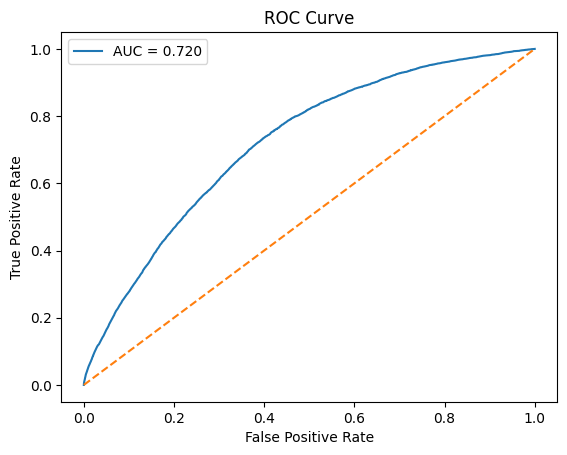

In [18]:
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

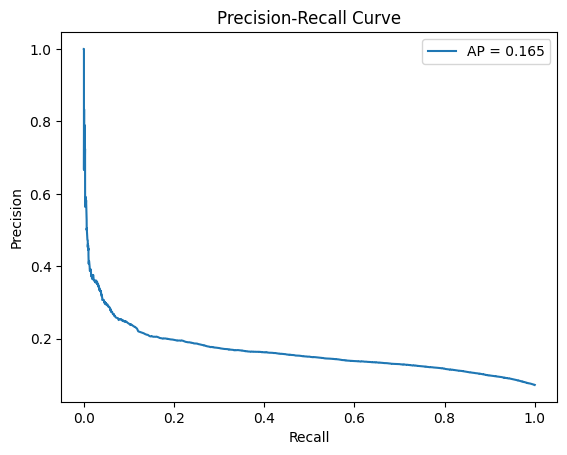

In [19]:
precision, recall, _ = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

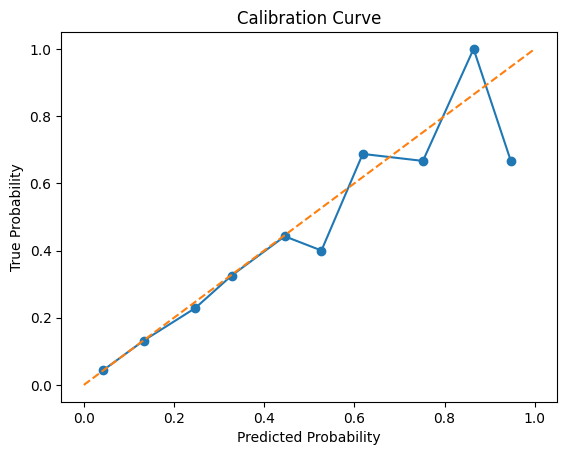

In [20]:
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve")
plt.show()